## Importing Libraries

In [1]:
import pandas as pd
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report , confusion_matrix, ConfusionMatrixDisplay
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Reading Data

In [3]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("transaction-train", version="1")

train_df = pd.read_csv(data_asset.path)
train_df.head()

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,is_fraud,account_type,transaction_type,transaction_amount,transaction_direction,merchant_category,state,credit_score,loan_type,emi_amount,channel,kyc_status,transaction_hour,transaction_minute,prior_transaction_count,amount_to_average_ratio
0,0,Savings,POS,5098.14,Debit,Food & Dining,Tamil Nadu,407,None,0.00,Web,Verified,0,23,3,0.52
1,0,Current,RTGS,278744.72,Debit,Utilities,UP,846,None,0.00,ATM,Verified,20,38,4,82.28
2,0,Savings,UPI,2734.57,Credit,Travel,Delhi,597,None,0.00,API,Verified,17,45,3,2.25
3,0,Current,NEFT,43184.26,Credit,Salary,Rajasthan,570,Personal,5084.36,Mobile_App,Verified,18,32,4,2.25
4,0,Savings,Net_Banking,10185.66,Credit,Salary,Gujarat,835,None,0.00,ATM,Verified,5,8,7,0.30


In [4]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("transaction-test", version="1")

test_df = pd.read_csv(data_asset.path)
test_df.head()

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,is_fraud,account_type,transaction_type,transaction_amount,transaction_direction,merchant_category,state,credit_score,loan_type,emi_amount,channel,kyc_status,transaction_hour,transaction_minute,prior_transaction_count,amount_to_average_ratio
0,0,Current,ATM_Withdrawal,1000.00,Debit,Food & Dining,Rajasthan,480,None,0.00,Mobile_App,Verified,7,4,0,1.00
1,0,Savings,UPI,233.14,Credit,Salary,Maharashtra,616,None,0.00,Web,Verified,19,16,8,0.07
2,0,Current,POS,1739.20,Debit,Retail,Maharashtra,527,None,0.00,Mobile_App,Verified,15,34,0,1.00
3,0,NRI,RTGS,212734.26,Credit,Entertainment,Rajasthan,779,Unknown,2137.89,Web,Verified,9,54,8,24.03
4,0,Savings,UPI,1529.61,Credit,Real Estate,Tamil Nadu,844,None,0.00,Mobile_App,Verified,20,49,3,0.10


In [127]:
onhot_features = ['account_type', 'transaction_direction', 'kyc_status', 'channel']
freq_features = ['transaction_type', 'merchant_category', 'state', 'loan_type']
skew_features = ['transaction_amount', 'emi_amount']
norm_features = ['credit_score', 'transaction_hour', 'transaction_minute','prior_transaction_count','amount_to_average_ratio']


In [6]:
X = train_df.drop(columns=['is_fraud'])
y = train_df['is_fraud']

test_X = test_df.drop(columns=['is_fraud'])
test_y = test_df['is_fraud']

## Creating Custom transformers

In [118]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        # scikit-learn convention: all init args must be stored as attributes
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        """
        Fit the encoder by calculating frequency of values in given columns.
        """
        if self.columns is None:
            self.columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        for col in self.columns:
            freq_map = X[col].value_counts(normalize=self.normalize).to_dict()
            self.freq_maps[col] = freq_map
        return self

    def transform(self, X):
        """
        Transform the dataframe using the fitted frequency maps.
        """
        X_transformed = X.copy()
        for col in self.columns:
            X_transformed[col] = X_transformed[col].map(self.freq_maps[col])
        return X_transformed
        
    def get_feature_names_out(self, input_features=None):
        # Return the same column names (since we don’t expand them)
        return self.columns


## Training Model

In [128]:
# Preprocessing: different transformers for different sets of columns
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), onhot_features),
        ('frequency', FrequencyEncoder(),freq_features),
        ('num', StandardScaler(), norm_features),
        ('log', FunctionTransformer(np.log1p, validate=True), skew_features)
    ]
)

# Full pipeline: preprocessing + model
pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('impute', SimpleImputer(strategy='mean')),
    ("smote", SMOTE(sampling_strategy=.7,random_state=42)),
    ('model', LogisticRegression(max_iter=300))
])

# Fit the pipeline
pipeline.fit(X, y)

# Evaluate
print("Train score:", pipeline.score(X, y))
print("Test score:", pipeline.score(test_X, test_y))


Train score: 0.9104880791898161
Test score: 0.9092132216579193


## Testing the Model

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     81770
           1       0.02      0.15      0.03       731

    accuracy                           0.92     82501
   macro avg       0.50      0.54      0.49     82501
weighted avg       0.98      0.92      0.95     82501



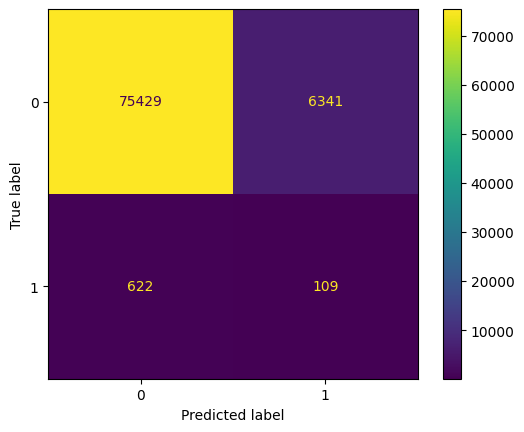

In [115]:
pred_y = pipeline.predict(test_X)
report = classification_report(test_y, pred_y)
print(report)

con_mat = confusion_matrix(test_y, pred_y)
ConfusionMatrixDisplay(con_mat).plot()

## Shap Explaination

In [129]:
onehot = list(pipeline[0]['onehot'].get_feature_names_out())
feature_names = onehot + freq_features + norm_features + skew_features

# --- Separate preprocessing and model for SHAP ---
# Transform X with preprocessing + imputation only
preproc_impute = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('impute', SimpleImputer(strategy='mean'))
])

X_enc = preproc_impute.fit_transform(X)   # encoded + imputed features

# Get model
model = pipeline.named_steps['model']

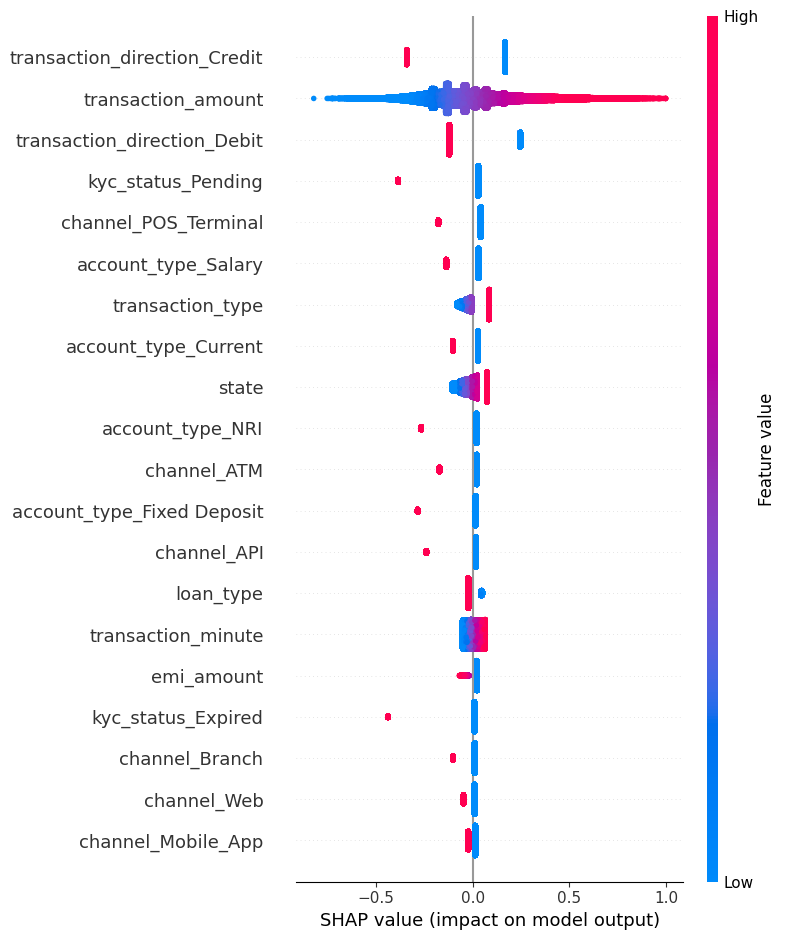

In [130]:
# SHAP explainer
explainer = shap.Explainer(model, X_enc)
explainer.feature_names = feature_names
shap_values = explainer(X_enc)

# Plot
shap.summary_plot(shap_values, features=X_enc)


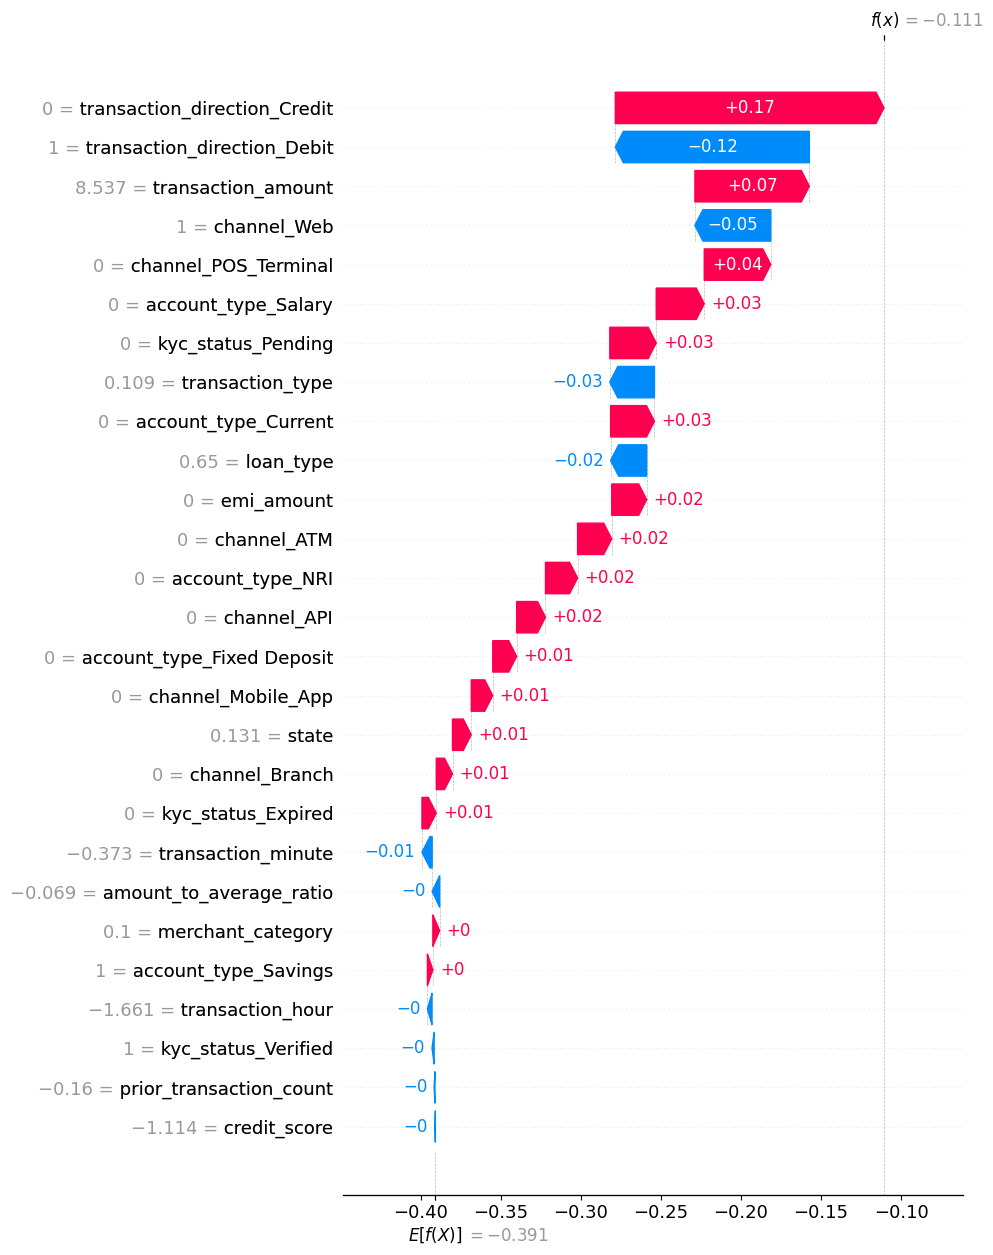

In [135]:
shap.plots.waterfall(shap_values[0], max_display=30)

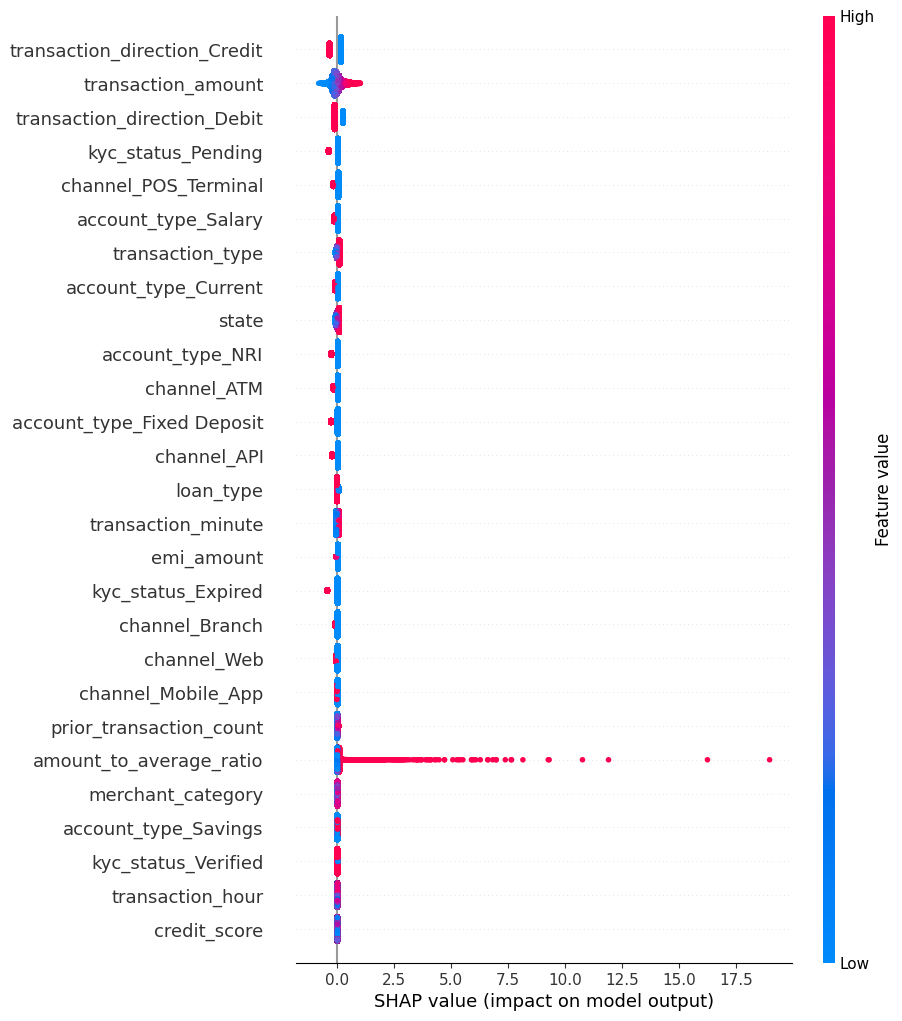

In [137]:
shap.plots.beeswarm(shap_values, max_display=30)

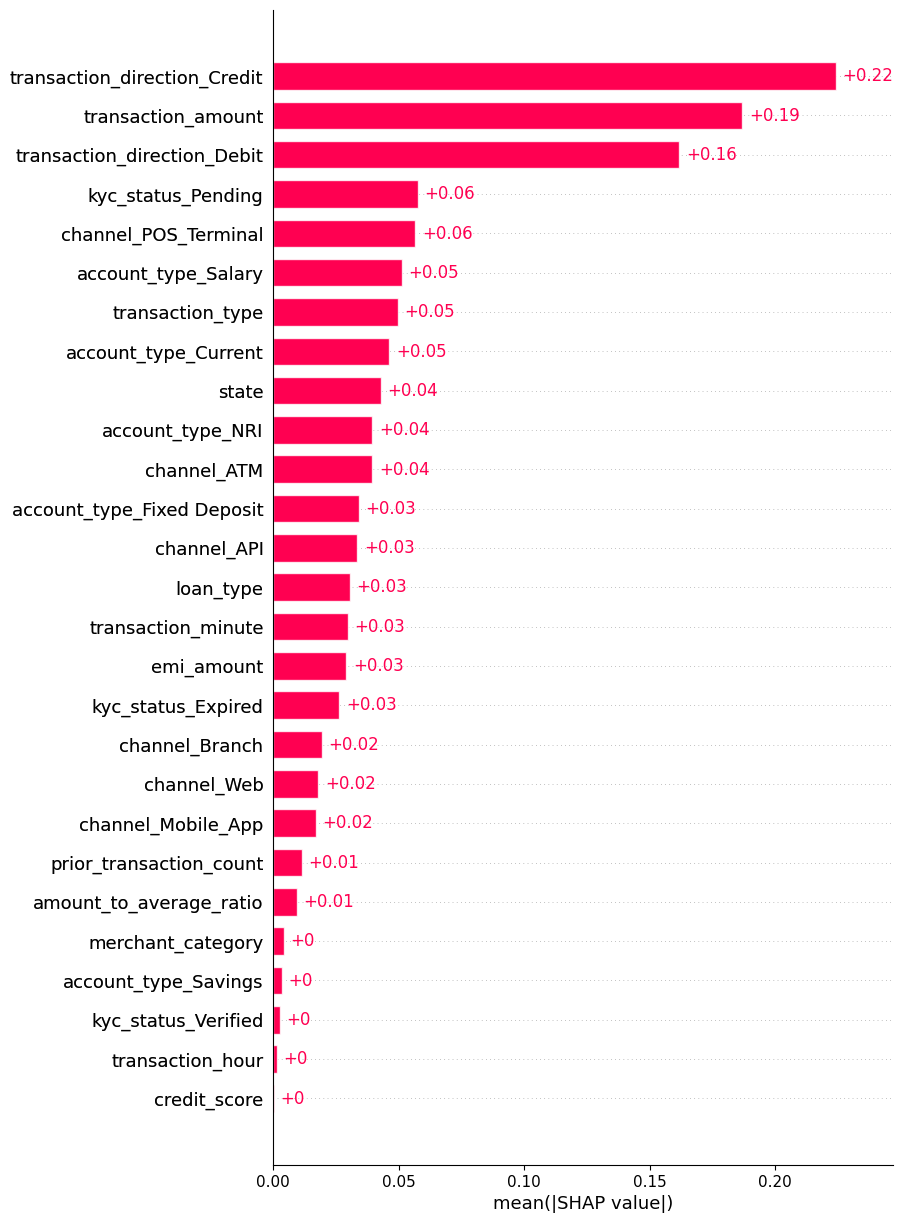

In [139]:
shap.plots.bar(shap_values, max_display=30)

### Shap Report

* `amount_to_average_ratio` show the highest contribution.
* The `transaction_amount` has a significant contribution.

